In [1]:
#Step 1

import os
import glob
import pandas as pd
import nibabel as nib
import numpy as np


base_path = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
subjects = ['sub-1', 'sub-2']
report_list = []

for sub in subjects:
    sub_path = os.path.join(base_path, sub)
    
    anat_files = glob.glob(os.path.join(sub_path, 'anat', 'wc*.nii'))
    anat_status = "Found" if anat_files else "Missing"

    rest_dir = os.path.join(sub_path, 'func', 'rest')
    rest_nii = glob.glob(os.path.join(rest_dir, '*.nii'))[0]
    rest_rp = glob.glob(os.path.join(rest_dir, 'rp_*.txt'))[0]

    img_rest = nib.load(rest_nii)
    rest_vols = img_rest.shape[3]
    rest_tr = img_rest.header.get_zooms()[3]
    
    df_rest_rp = pd.read_csv(rest_rp, sep=r'\s+', header=None)
    rest_qc = "Pass" if len(df_rest_rp) == rest_vols else "Fail"

    task_dir = os.path.join(sub_path, 'func', 'stopsignal_task')
    task_nii = glob.glob(os.path.join(task_dir, '*task-stopsignal_bold.nii'))[0]
    task_rp = glob.glob(os.path.join(task_dir, 'rp_*.txt'))[0]
    task_events = glob.glob(os.path.join(task_dir, '*events.tsv'))[0]

    img_task = nib.load(task_nii)
    task_vols = img_task.shape[3]
    task_tr = img_task.header.get_zooms()[3]
    task_duration = task_vols * task_tr

    df_task_rp = pd.read_csv(task_rp, sep=r'\s+', header=None)
    task_confounds_qc = "Pass" if len(df_task_rp) == task_vols else "Fail"

    df_events = pd.read_csv(task_events, sep='\t')
    last_event_time = (df_events['onset'] + df_events['duration']).max()
    task_timing_qc = "Pass" if last_event_time <= task_duration else "Fail"

    report_list.append({
        "Subject": sub,
        "Anat": anat_status,
        "Rest_Vols": rest_vols,
        "Rest_TR": rest_tr,
        "Rest_Motion_QC": rest_qc,
        "Task_Vols": task_vols,
        "Task_TR": task_tr,
        "Task_Motion_QC": task_confounds_qc,
        "Task_Timing_QC": task_timing_qc
    })

df_final_report = pd.DataFrame(report_list)
print(df_final_report)



  Subject   Anat  Rest_Vols  Rest_TR Rest_Motion_QC  Task_Vols  Task_TR  \
0   sub-1  Found        152      2.0           Pass        184      2.0   
1   sub-2  Found        152      2.0           Pass        184      2.0   

  Task_Motion_QC Task_Timing_QC  
0           Pass           Pass  
1           Pass           Pass  


Processing Motion with FD Threshold = 0.5mm...



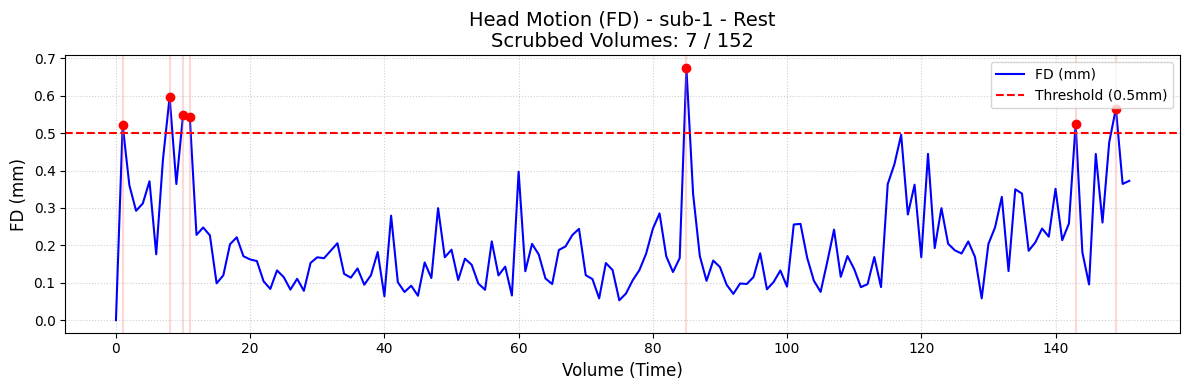

✅ sub-1 - Rest: Confounds saved to CSV.
   Total Frames: 152 | High Motion Frames (>0.5mm): 7
--------------------------------------------------


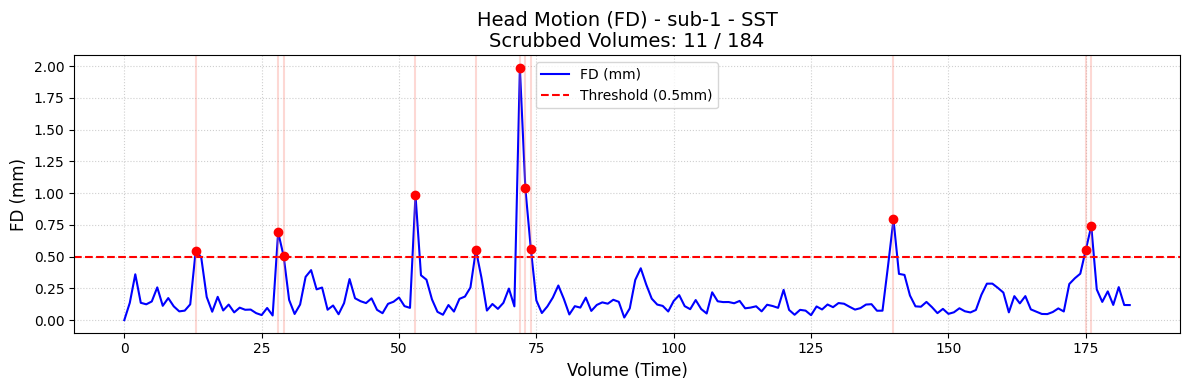

✅ sub-1 - SST: Confounds saved to CSV.
   Total Frames: 184 | High Motion Frames (>0.5mm): 11
--------------------------------------------------


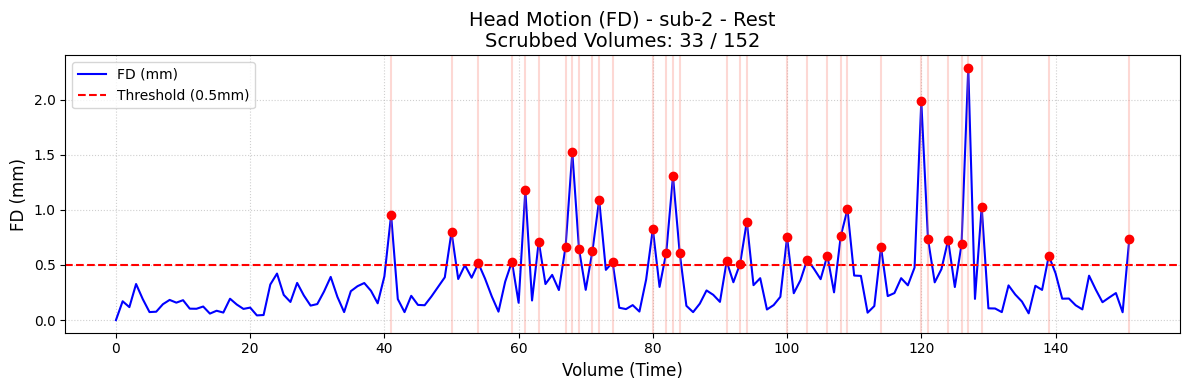

✅ sub-2 - Rest: Confounds saved to CSV.
   Total Frames: 152 | High Motion Frames (>0.5mm): 33
--------------------------------------------------


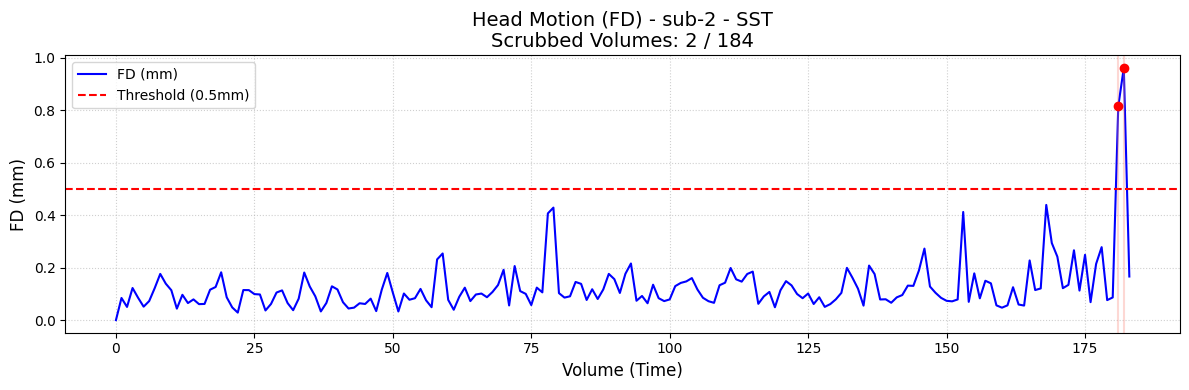

✅ sub-2 - SST: Confounds saved to CSV.
   Total Frames: 184 | High Motion Frames (>0.5mm): 2
--------------------------------------------------


In [2]:
#step2
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']
FD_THRESHOLD = 0.5  

def compute_fd(motion_params):

    # تبدیل به آرایه نامپای
    mp = np.array(motion_params)
    
    delta_mp = np.diff(mp, axis=0, prepend=mp[0].reshape(1, -1))
    
    delta_trans = delta_mp[:, :3]
    delta_rot = delta_mp[:, 3:]
    
    delta_rot_mm = delta_rot * 50
    
    fd = np.sum(np.abs(delta_trans), axis=1) + np.sum(np.abs(delta_rot_mm), axis=1)
    return fd

def compute_24hmp(motion_params):
   
  
    df = pd.DataFrame(motion_params)

    R = df.values

    R_prime = np.zeros_like(R)
    R_prime[1:] = np.diff(R, axis=0)
 
    R_sq = R ** 2
    
    R_prime_sq = R_prime ** 2
    
    
    return np.hstack([R, R_prime, R_sq, R_prime_sq])

def make_scrubbing_regressors(fd_series, threshold):
    
    bad_volumes = np.where(fd_series > threshold)[0]
    n_vols = len(fd_series)
    
    if len(bad_volumes) == 0:
        return pd.DataFrame() # هیچ نقطه‌ای حذف نمی‌شود
    
    # ساخت ماتریس One-Hot برای نقاط خراب
    scrub_matrix = np.zeros((n_vols, len(bad_volumes)))
    col_names = []
    
    for i, vol_idx in enumerate(bad_volumes):
        scrub_matrix[vol_idx, i] = 1
        col_names.append(f'scrub_vol_{vol_idx}')
        
    return pd.DataFrame(scrub_matrix, columns=col_names)

print(f"Processing Motion with FD Threshold = {FD_THRESHOLD}mm...\n")

for sub in SUBJECTS:
    sub_dir = os.path.join(BASE_PATH, sub)
    
   
    tasks = {
        'Rest': os.path.join(sub_dir, 'func', 'rest', 'rp_*.txt'),
        'SST': os.path.join(sub_dir, 'func', 'stopsignal_task', 'rp_*.txt')
    }
    
    for task_name, rp_pattern in tasks.items():
        rp_files = glob.glob(rp_pattern)
        if not rp_files:
            continue
            
        rp_file = rp_files[0]
        
   
        motion_df = pd.read_csv(rp_file, sep=r'\s+', header=None, names=['x','y','z','rx','ry','rz'])
        
        # 2. محاسبه FD
        fd_values = compute_fd(motion_df)
        
        # 3. محاسبه 24 پارامتر
        hmp_24 = compute_24hmp(motion_df)
        cols_24 = [f'mot_{i}' for i in range(1, 25)]
        df_24hmp = pd.DataFrame(hmp_24, columns=cols_24)
        
        # 4. ساخت اسکرابینگ
        df_scrub = make_scrubbing_regressors(fd_values, FD_THRESHOLD)
        n_scrubs = df_scrub.shape[1]
        
      
        final_confounds = pd.concat([df_24hmp, pd.Series(fd_values, name='FD'), df_scrub], axis=1)
        
      
        save_path = rp_file.replace('.txt', '_confounds_full.csv')
        final_confounds.to_csv(save_path, index=False)
        
     
        plt.figure(figsize=(12, 4))
        plt.plot(fd_values, label='FD (mm)', color='blue', linewidth=1.5)
        plt.axhline(y=FD_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({FD_THRESHOLD}mm)')
        
       
        bad_indices = np.where(fd_values > FD_THRESHOLD)[0]
        if len(bad_indices) > 0:
            plt.scatter(bad_indices, fd_values[bad_indices], color='red', zorder=5)
            # هایلایت کردن ستون‌ها
            for idx in bad_indices:
                plt.axvline(x=idx, color='salmon', alpha=0.3)
                
        plt.title(f'Head Motion (FD) - {sub} - {task_name}\nScrubbed Volumes: {n_scrubs} / {len(fd_values)}', fontsize=14)
        plt.xlabel('Volume (Time)', fontsize=12)
        plt.ylabel('FD (mm)', fontsize=12)
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()
        
        print(f"✅ {sub} - {task_name}: Confounds saved to CSV.")
        print(f"   Total Frames: {len(fd_values)} | High Motion Frames (>0.5mm): {n_scrubs}")
        print("-" * 50)



🧠 Processing Subject: sub-1
   -> BOLD: 184 volumes, TR=2.00s
   -> Events loaded: ['GO' 'STOP']
   -> Design Matrix Shape: (184, 46)


C:\Users\user\AppData\Local\Temp\ipykernel_11504\1170837160.py:76: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


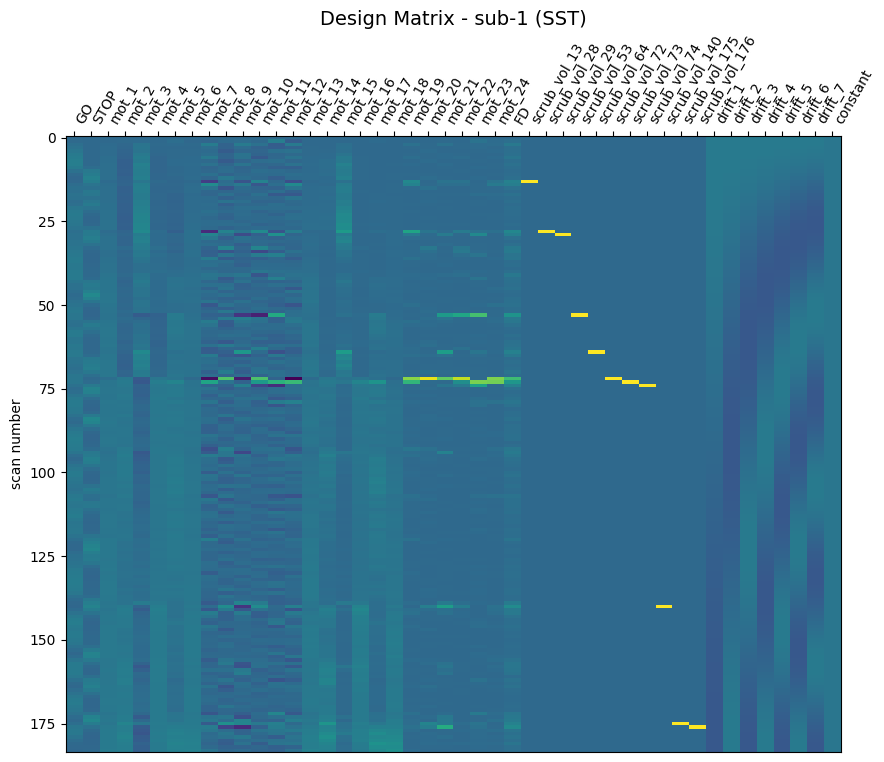

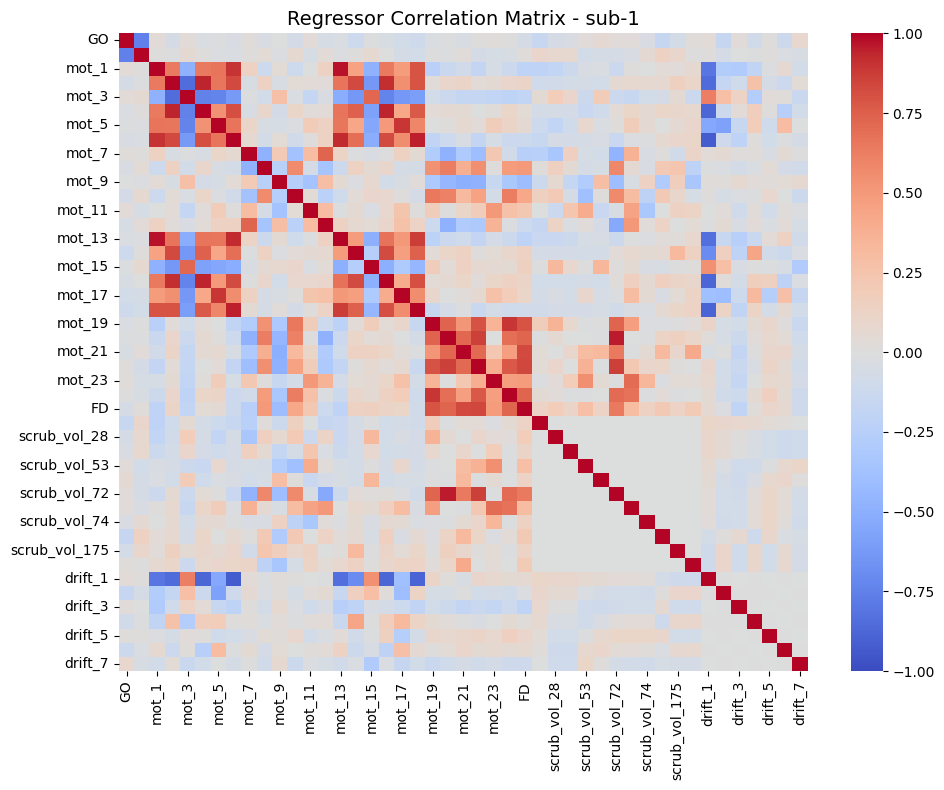


🧠 Processing Subject: sub-2
   -> BOLD: 184 volumes, TR=2.00s
   -> Events loaded: ['GO' 'STOP']
   -> Design Matrix Shape: (184, 37)


C:\Users\user\AppData\Local\Temp\ipykernel_11504\1170837160.py:76: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


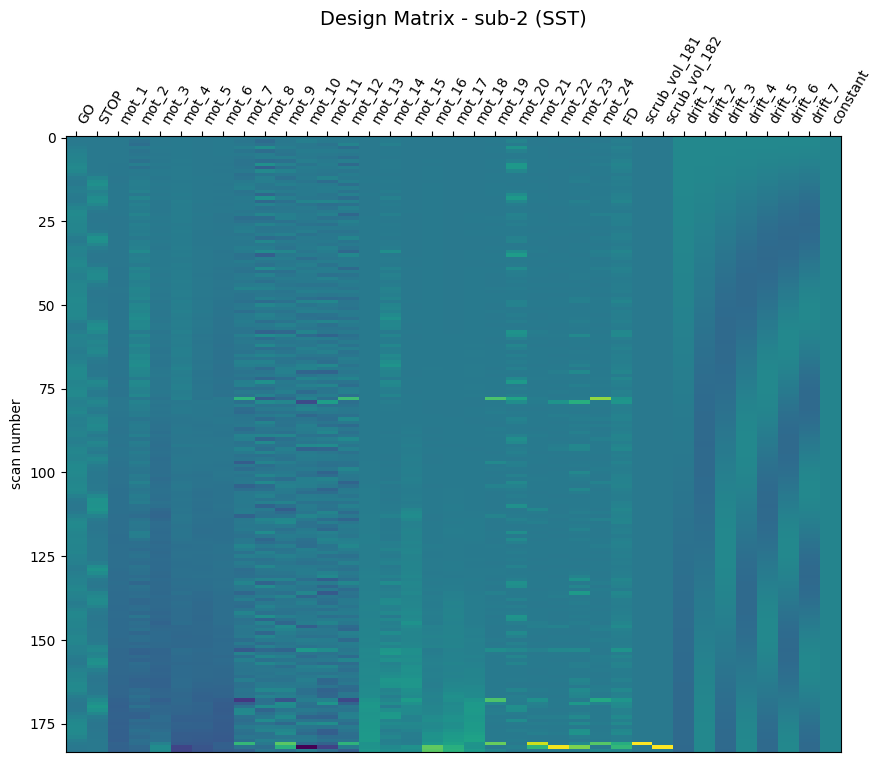

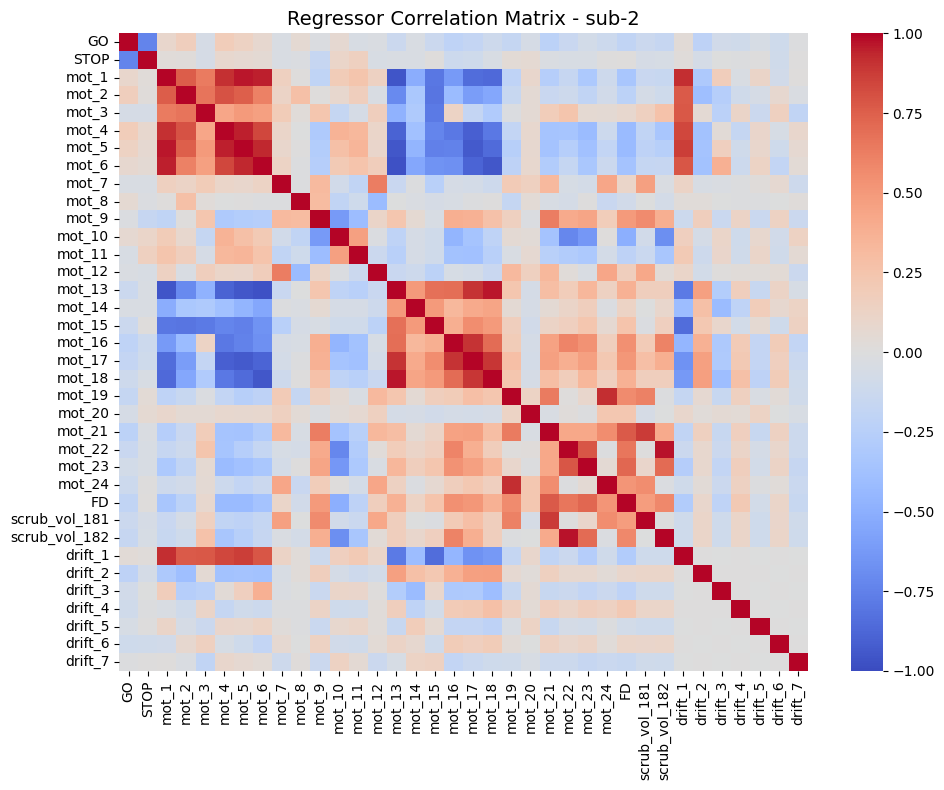

In [3]:
#step3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix, plot_matrix
import nibabel as nib
import os
import glob

BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']



for sub in SUBJECTS:
    print(f"\n🧠 Processing Subject: {sub}")
    sub_dir = os.path.join(BASE_PATH, sub)
    task_dir = os.path.join(sub_dir, 'func', 'stopsignal_task')
    
   
    nii_files = glob.glob(os.path.join(task_dir, '*task-stopsignal_bold.nii'))
    if not nii_files:
        print(f"❌ Error: BOLD file not found for {sub}")
        continue
    nii_file = nii_files[0]
    
    img = nib.load(nii_file)
    n_scans = img.shape[3]
    tr = img.header.get_zooms()[3]
    
   
    frame_times = np.arange(n_scans) * tr
    
    print(f"   -> BOLD: {n_scans} volumes, TR={tr:.2f}s")
    

    events_file = glob.glob(os.path.join(task_dir, '*events.tsv'))[0]
    events_df = pd.read_csv(events_file, sep='\t')
    
  
    events_df = events_df[['onset', 'duration', 'trial_type']].dropna()
    
    # نمایش خلاصه ایونت‌ها
    unique_conditions = events_df['trial_type'].unique()
    print(f"   -> Events loaded: {unique_conditions}")
    
    confound_files = glob.glob(os.path.join(task_dir, '*_confounds_full.csv'))
    
    if confound_files:
        confounds_df = pd.read_csv(confound_files[0])
        # چک کردن سایز
        if len(confounds_df) != n_scans:
            print(f"❌ Mismatch! Confounds rows ({len(confounds_df)}) != Scans ({n_scans})")
            confounds_df = confounds_df.iloc[:n_scans, :]
    else:
        print("Warning: Confound file not found! Making design matrix without confounds.")
        confounds_df = None

 
    design_matrix = make_first_level_design_matrix(
        frame_times=frame_times,
        events=events_df,
        hrf_model='spm',      
        drift_model='cosine', 
        high_pass=0.01,       
        add_regs=confounds_df,
        add_reg_names=confounds_df.columns.tolist() if confounds_df is not None else None
    )
    
    print(f"   -> Design Matrix Shape: {design_matrix.shape}")

  
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_design_matrix(design_matrix, ax=ax)
    plt.title(f'Design Matrix - {sub} (SST)', fontsize=14)
    plt.show()
    
  
    dm_corr = design_matrix.drop(columns=['constant']).corr()
    
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(dm_corr, cmap='coolwarm', vmin=-1, vmax=1, center=0)
    plt.title(f'Regressor Correlation Matrix - {sub}', fontsize=14)
    plt.tight_layout()
    plt.show()




In [ ]:
#step4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting
import nibabel as nib
import os
import glob

BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']


for sub in SUBJECTS:
    print(f"\n🧠 Processing Subject: {sub}")
    sub_dir = os.path.join(BASE_PATH, sub)
    task_dir = os.path.join(sub_dir, 'func', 'stopsignal_task')
    anat_file = os.path.join(sub_dir, 'anat', f'wc{sub}_T1w.nii')
    
    # 1. پیدا کردن فایل‌ها
    nii_file = glob.glob(os.path.join(task_dir, '*task-stopsignal_bold.nii'))[0]
    events_file = glob.glob(os.path.join(task_dir, '*events.tsv'))[0]
    confounds_file = glob.glob(os.path.join(task_dir, '*_confounds_full.csv'))[0]
    
    # اصلاح TR
    img = nib.load(nii_file)
    tr = float(img.header.get_zooms()[3])
    confounds_df = pd.read_csv(confounds_file).iloc[:img.shape[3], :]
    
    # 2. تمیز کردن ایونت‌ها (Fixing NaN & Names)
    events_df = pd.read_csv(events_file, sep='\t')
    
    # حذف ردیف‌هایی که trial_type ندارند (حذف nan)
    events_df = events_df.dropna(subset=['trial_type'])
    
    # چاپ نام‌های پیدا شده برای اطمینان
    conditions = events_df['trial_type'].unique()
    print(f"   -> Conditions found: {conditions}")
    
    # 3. فیت کردن مدل
    print("   -> Fitting GLM...")
    fmri_glm = FirstLevelModel(
        t_r=tr,
        noise_model='ar1',
        standardize=False,       
        hrf_model='spm',
        drift_model='cosine',
        high_pass=0.01,
        smoothing_fwhm=6.0,
        minimize_memory=False
    )
    fmri_glm = fmri_glm.fit(nii_file, events=events_df, confounds=confounds_df)
    
    # 4. تعریف کنتراست‌ها (بر اساس نام‌های واقعی GO و STOP)
    design_cols = fmri_glm.design_matrices_[0].columns
    contrasts = {}
    
    # لاجیک جدید: استفاده از حروف بزرگ طبق دیتای شما
    if 'STOP' in design_cols and 'GO' in design_cols:
        contrasts['Stop > Go'] = 'STOP - GO'  # ترمز > گاز
        contrasts['Go > Stop'] = 'GO - STOP'  # گاز > ترمز
    else:
        print(f"❌ ERROR: Still mismatch! Columns found: {design_cols}")
        continue
    
 
    for contrast_name, contrast_expr in contrasts.items():
        print(f"   -> Visualizing: {contrast_name}")
        z_map = fmri_glm.compute_contrast(contrast_expr, output_type='z_score')
        
       
        fig_glass = plt.figure(figsize=(10, 4))
        plotting.plot_glass_brain(
            z_map, 
            colorbar=True, 
            threshold=3.0, 
            title=f'{sub}: {contrast_name} (Glass Brain)',
            plot_abs=False, 
            display_mode='lyrz',
            figure=fig_glass
        )
        plt.show()
        
      
        fig_stat = plt.figure(figsize=(10, 4))
        plotting.plot_stat_map(
            z_map, 
            bg_img=anat_file, 
            threshold=3.0,
            title=f'{sub}: {contrast_name} (Anatomy)',
            cut_coords=(0, 0, 10),
            display_mode='ortho',
            cmap='cold_hot',
            figure=fig_stat
        )
        plt.show()









🧠 Processing Subject: sub-1
   -> Conditions found: ['GO' 'STOP']
   -> Fitting GLM...


C:\Users\user\AppData\Local\Temp\ipykernel_11504\3624128243.py:54: UserWarning: The following unexpected columns in events data will be ignored: TrialOutcome, StopSignalDelay, SubjectResponseCorrectness, ReactionTime, LadderTime, SubjectResponseButtonCode, PresentedStimulusArrowDirection, TimeCourse, SubjectResponseButton, LadderNumber, TimeCourse_noTriggerAdjust, onset_noTriggerAdjust, LadderMovement
  fmri_glm = fmri_glm.fit(nii_file, events=events_df, confounds=confounds_df)



 Processing sub-1...
   -> Fitting First Level GLM...


C:\Users\user\AppData\Local\Temp\ipykernel_8780\284005389.py:41: UserWarning: The following unexpected columns in events data will be ignored: TimeCourse_noTriggerAdjust, TimeCourse, TrialOutcome, onset_noTriggerAdjust, PresentedStimulusArrowDirection, StopSignalDelay, SubjectResponseCorrectness, LadderTime, SubjectResponseButton, ReactionTime, LadderMovement, LadderNumber, SubjectResponseButtonCode
  fmri_glm = fmri_glm.fit(nii_file, events=events_df, confounds=confounds_df)


   ✅ Saved map to: sub-1_Stop_vs_Go_zmap.nii.gz

 Processing sub-2...
   -> Fitting First Level GLM...


C:\Users\user\AppData\Local\Temp\ipykernel_8780\284005389.py:41: UserWarning: The following unexpected columns in events data will be ignored: TimeCourse_noTriggerAdjust, TimeCourse, TrialOutcome, onset_noTriggerAdjust, PresentedStimulusArrowDirection, StopSignalDelay, SubjectResponseCorrectness, LadderTime, SubjectResponseButton, ReactionTime, LadderMovement, LadderNumber, SubjectResponseButtonCode
  fmri_glm = fmri_glm.fit(nii_file, events=events_df, confounds=confounds_df)


   ✅ Saved map to: sub-2_Stop_vs_Go_zmap.nii.gz


================ TASK 5: GROUP ANALYSIS ================
Found 2 maps. Running Second Level GLM...
Visualizing Group Map...


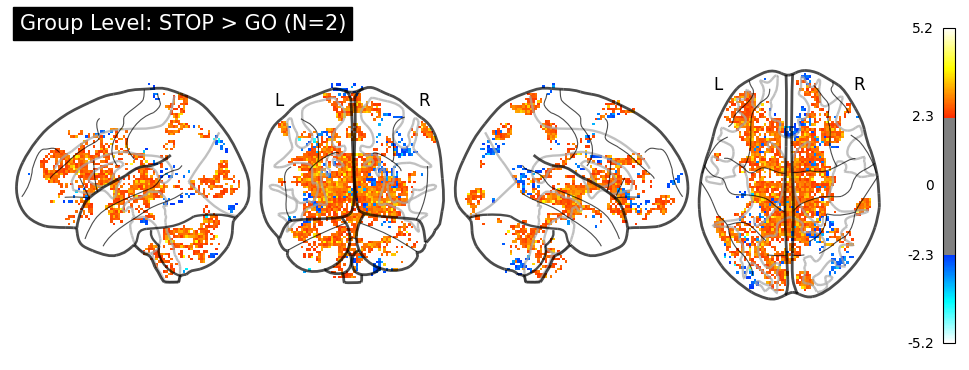

✅ Group Analysis Complete!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm.second_level import SecondLevelModel
from nilearn import plotting
import nibabel as nib
import os
import glob

# --- تنظیمات ---
BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']

saved_maps = [] 

for sub in SUBJECTS:
    print(f"\n Processing {sub}...")
    sub_dir = os.path.join(BASE_PATH, sub)
    task_dir = os.path.join(sub_dir, 'func', 'stopsignal_task')
    
  
    nii_file = glob.glob(os.path.join(task_dir, '*task-stopsignal_bold.nii'))[0]
    events_file = glob.glob(os.path.join(task_dir, '*events.tsv'))[0]
    confounds_file = glob.glob(os.path.join(task_dir, '*_confounds_full.csv'))[0]
 
    img = nib.load(nii_file)
    tr = float(img.header.get_zooms()[3])
    confounds_df = pd.read_csv(confounds_file).iloc[:img.shape[3], :]
    
    
    events_df = pd.read_csv(events_file, sep='\t')
    events_df = events_df.dropna(subset=['trial_type'])
    
   
    print("   -> Fitting First Level GLM...")
    fmri_glm = FirstLevelModel(
        t_r=tr, noise_model='ar1', standardize=False,       
        hrf_model='spm', drift_model='cosine', high_pass=0.01,
        smoothing_fwhm=6.0, minimize_memory=False
    )
    fmri_glm = fmri_glm.fit(nii_file, events=events_df, confounds=confounds_df)
    
   
    design_cols = fmri_glm.design_matrices_[0].columns
    
    if 'STOP' in design_cols and 'GO' in design_cols:
     
        z_map = fmri_glm.compute_contrast('STOP - GO', output_type='z_score')
        
        
        safe_filename = f'{sub}_Stop_vs_Go_zmap.nii.gz'
        save_path = os.path.join(task_dir, safe_filename)
        
        z_map.to_filename(save_path)
        saved_maps.append(save_path)
        print(f"   ✅ Saved map to: {safe_filename}")
        
    else:
        print(f"   ❌ ERROR: Conditions STOP/GO not found for {sub}")

# ========================================================
print("\n\n================ TASK 5: GROUP ANALYSIS ================")

if len(saved_maps) == len(SUBJECTS):
    print(f"Found {len(saved_maps)} maps. Running Second Level GLM...")
    
    # ساخت ماتریس طراحی گروهی
    design_matrix = pd.DataFrame(
        {'intercept': [1] * len(saved_maps)},
        index=SUBJECTS
    )
    
    # فیت مدل گروهی
    second_level_model = SecondLevelModel(smoothing_fwhm=8.0, n_jobs=1)
    second_level_model = second_level_model.fit(saved_maps, design_matrix=design_matrix)
    
    # محاسبه و نمایش
    z_map_group = second_level_model.compute_contrast(output_type='z_score')
    
    print("Visualizing Group Map...")
    plotting.plot_glass_brain(
        z_map_group,
        threshold=2.3,
        colorbar=True,
        display_mode='lyrz',
        plot_abs=False,
        title='Group Level: STOP > GO (N=2)',
        cmap='cold_hot'
    )
    plt.show()
    print("✅ Group Analysis Complete!")
    
else:
    print("❌ Not enough maps generated to run Group Analysis.")


Loading Harvard-Oxford Atlas...
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\user\nilearn_data\fsl
   ✅ Seed 'Cingulate Gyrus, posterior division' found at index 30

🧠 Processing Connectivity for: sub-1


C:\Users\user\AppData\Local\Temp\ipykernel_8780\2469809689.py:60: RuntimeWarning: divide by zero encountered in arctanh
  fisher_z_matrix = np.arctanh(correlation_matrix)


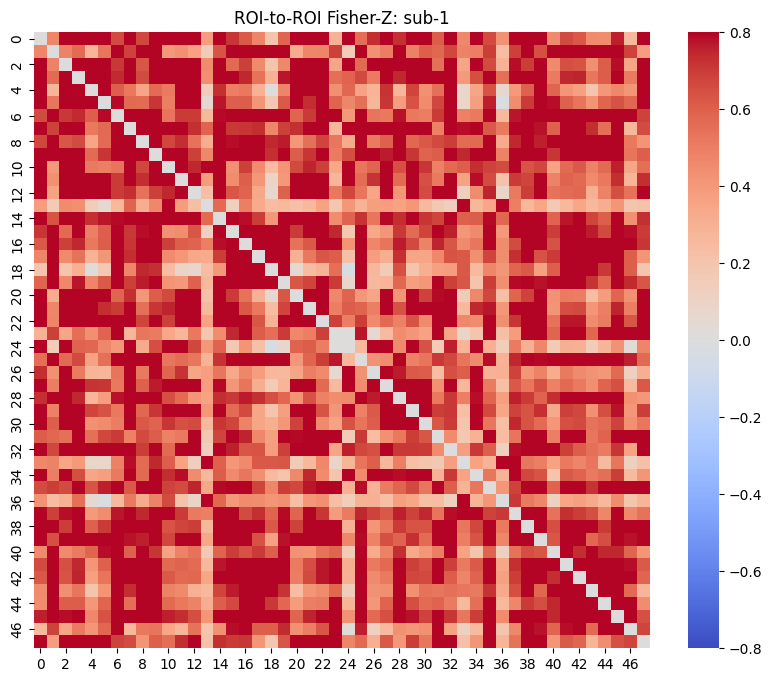

      -> Matrix saved to sub-1_roi_fisherz.csv


C:\Users\user\AppData\Local\Temp\ipykernel_8780\2469809689.py:81: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_nii = clean_img(
C:\Users\user\AppData\Local\Temp\ipykernel_8780\2469809689.py:107: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(


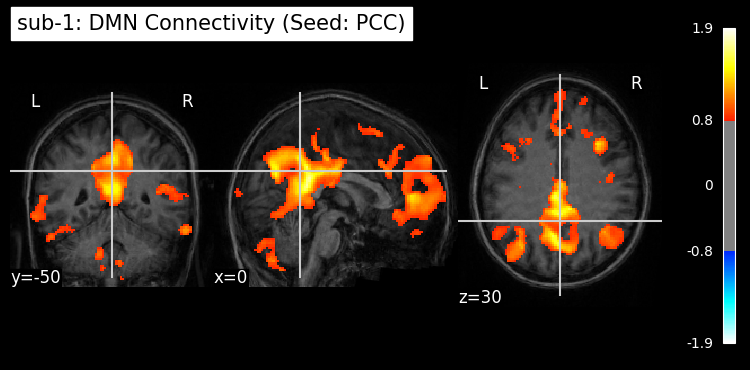

      -> Seed map saved to sub-1_seedPCC_zmap.nii.gz

🧠 Processing Connectivity for: sub-2


C:\Users\user\AppData\Local\Temp\ipykernel_8780\2469809689.py:60: RuntimeWarning: divide by zero encountered in arctanh
  fisher_z_matrix = np.arctanh(correlation_matrix)


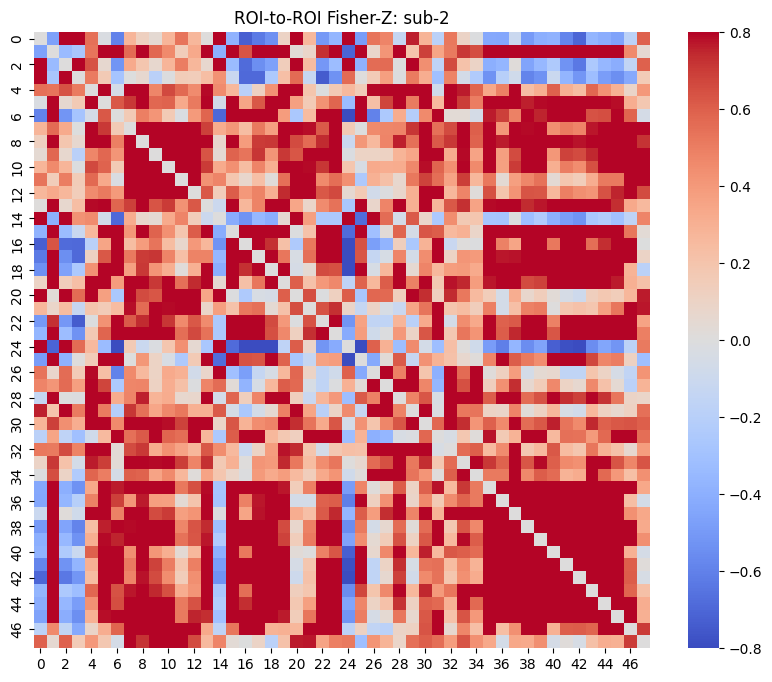

      -> Matrix saved to sub-2_roi_fisherz.csv


C:\Users\user\AppData\Local\Temp\ipykernel_8780\2469809689.py:81: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_nii = clean_img(
C:\Users\user\AppData\Local\Temp\ipykernel_8780\2469809689.py:107: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(


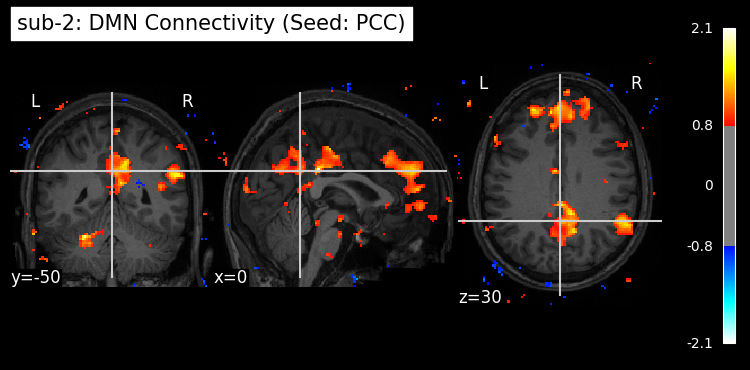

      -> Seed map saved to sub-2_seedPCC_zmap.nii.gz


In [ ]:
#step 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, plotting, image, maskers
from nilearn.input_data import NiftiLabelsMasker, NiftiSpheresMasker
import nibabel as nib
import os
import glob

BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']


print("Loading Harvard-Oxford Atlas...")
dataset = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_filename = dataset.maps
labels = dataset.labels 
seed_label = 'Cingulate Gyrus, posterior division'
try:
   
    seed_index = labels.index(seed_label) 
    print(f"   ✅ Seed '{seed_label}' found at index {seed_index}")
except ValueError:
    print(f"   ❌ Error: Seed label '{seed_label}' not found in atlas!")

for sub in SUBJECTS:
    print(f"\n🧠 Processing Connectivity for: {sub}")
    sub_dir = os.path.join(BASE_PATH, sub)
    rest_dir = os.path.join(sub_dir, 'func', 'rest')
    
    
    nii_file = glob.glob(os.path.join(rest_dir, '*.nii'))[0]
    # فایل confounds که در تسک 2 ساختیم
    confounds_file = glob.glob(os.path.join(rest_dir, '*_confounds_full.csv'))[0]
    
    # آماده‌سازی Confounds (برش زدن به اندازه ولوم‌ها)
    img = nib.load(nii_file)
    n_vols = img.shape[3]
    confounds_df = pd.read_csv(confounds_file).iloc[:n_vols, :]

    masker = NiftiLabelsMasker(
        labels_img=atlas_filename,
        standardize=True,
        memory='nilearn_cache',
        verbose=0,
        detrend=True,
        low_pass=0.1, high_pass=0.01, t_r=2.0, 
    )
    
  
    time_series = masker.fit_transform(nii_file, confounds=confounds_df)
    

    correlation_matrix = np.corrcoef(time_series.T)
    
    fisher_z_matrix = np.arctanh(correlation_matrix)

    np.fill_diagonal(fisher_z_matrix, 0)
    
    # رسم ماتریس (Heatmap)
    plt.figure(figsize=(10, 8))
    sns.heatmap(fisher_z_matrix, cmap='coolwarm', vmin=-0.8, vmax=0.8, square=True)
    plt.title(f'ROI-to-ROI Fisher-Z: {sub}')
    plt.show()
    
    df_corr = pd.DataFrame(fisher_z_matrix, columns=labels[1:], index=labels[1:])
    save_csv_path = os.path.join(rest_dir, f'{sub}_roi_fisherz.csv')
    df_corr.to_csv(save_csv_path)
    print(f"      -> Matrix saved to {os.path.basename(save_csv_path)}")

    
    seed_timeseries = time_series[:, seed_index - 1]
    
    from nilearn.image import clean_img
    
 
    clean_nii = clean_img(
        nii_file, 
        confounds=confounds_df,
        detrend=True, standardize=True,
        low_pass=0.1, high_pass=0.01, t_r=2.0
    )
    
    clean_data = clean_nii.get_fdata()
    
    

    seed_based_correlations = np.dot(clean_data, seed_timeseries) / n_vols
  
    
    
    seed_corr_img = image.new_img_like(clean_nii, seed_based_correlations)
    
    from nilearn.image import math_img
   
    seed_z_img = math_img("np.arctanh(np.clip(img, -0.999, 0.999))", img=seed_corr_img)
    
    # نمایش و ذخیره
    save_map_path = os.path.join(rest_dir, f'{sub}_seedPCC_zmap.nii.gz')
    seed_z_img.to_filename(save_map_path)
    

    plotting.plot_stat_map(
        seed_z_img, 
        bg_img=os.path.join(sub_dir, 'anat', f'wc{sub}_T1w.nii'),
        threshold=0.8,   
        title=f'{sub}: DMN Connectivity (Seed: PCC)',
        cut_coords=(0, -50, 30), 
        cmap='cold_hot'
    )
    plt.show()
    print(f"      -> Seed map saved to {os.path.basename(save_map_path)}")





[PART 1] Group ROI Analysis...
   ✅ Loaded matrix for sub-1
   ✅ Loaded matrix for sub-2


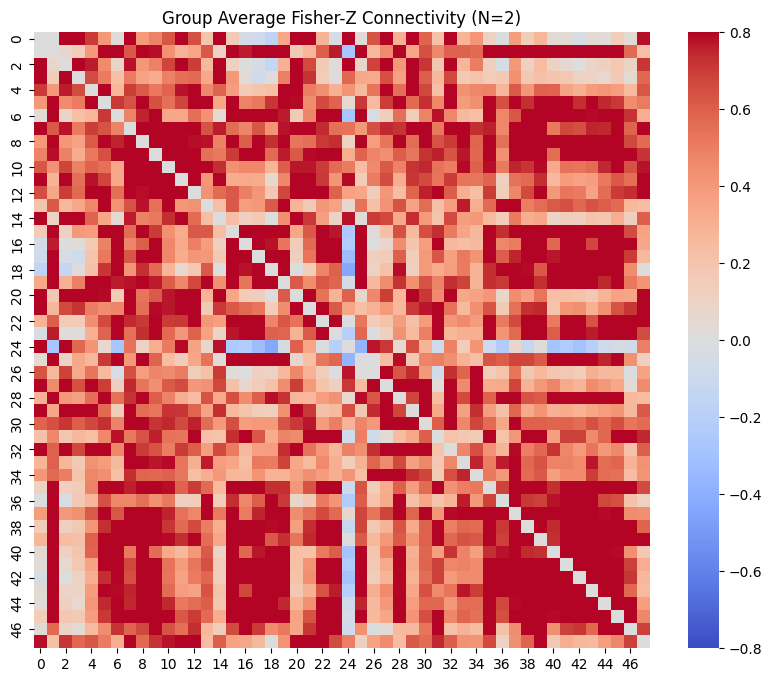

   -> Extracting DMN sub-network (4 nodes)...
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\user\nilearn_data\fsl


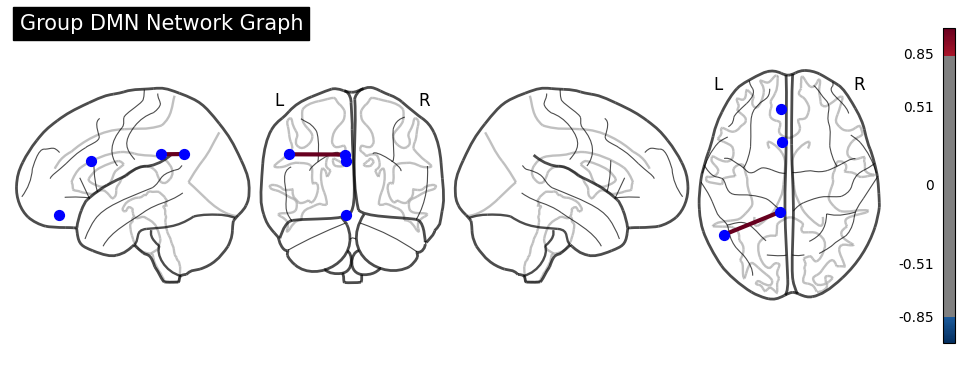


[PART 2] Group Seed-to-Voxel Map...
   ✅ Found seed map for sub-1
   ✅ Found seed map for sub-2


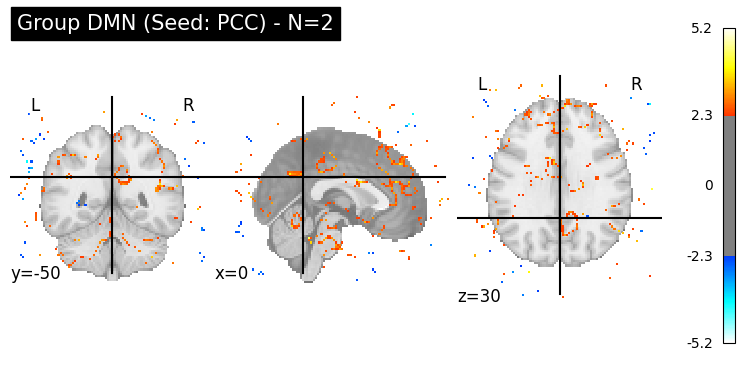

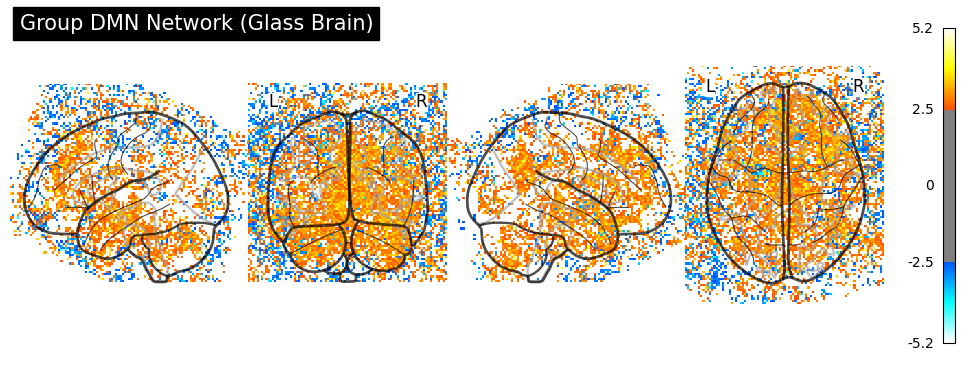

In [ ]:
#step7 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting, datasets
from nilearn.glm.second_level import SecondLevelModel
import os
import glob


BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']
print("\n[PART 1] Group ROI Analysis...")

roi_matrices = []

for sub in SUBJECTS:
    sub_dir = os.path.join(BASE_PATH, sub, 'func', 'rest')
 
    csv_path = glob.glob(os.path.join(sub_dir, '*_roi_fisherz.csv'))
    
    if csv_path:
        df = pd.read_csv(csv_path[0], index_col=0)
        roi_matrices.append(df.values)
        print(f"   ✅ Loaded matrix for {sub}")
    else:
        print(f"   ❌ Missing ROI matrix for {sub}")

if roi_matrices:
  
    group_matrix = np.mean(roi_matrices, axis=0)
    roi_labels = df.columns.tolist() 
    
  
    plt.figure(figsize=(10, 8))
    sns.heatmap(group_matrix, cmap='coolwarm', vmin=-0.8, vmax=0.8, square=True)
    plt.title('Group Average Fisher-Z Connectivity (N=2)')
    plt.show()
   
    dmn_keywords = [
        'Cingulate Gyrus, posterior division', # PCC
        'Precuneus',
        'Frontal Medial Cortex', # mPFC
        'Angular Gyrus',
        'Cingulate Gyrus, anterior division' # ACC
    ]

    selected_indices = []
    selected_labels = []
    
    for i, label in enumerate(roi_labels):

        if any(keyword in label for keyword in dmn_keywords):
            selected_indices.append(i)
            selected_labels.append(label)
            
    if selected_indices:
        print(f"   -> Extracting DMN sub-network ({len(selected_indices)} nodes)...")
        
      
        dmn_matrix = group_matrix[np.ix_(selected_indices, selected_indices)]
        
       
        atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
        coords = plotting.find_parcellation_cut_coords(atlas.maps)
        

        selected_coords = coords[selected_indices]
        
        
        plotting.plot_connectome(
            dmn_matrix, 
            selected_coords,
            edge_threshold="90%", 
            title="Group DMN Network Graph",
            node_color='blue',
            node_size=50,
            display_mode='lyrz'
        )
        plt.show()
    else:
        print("   ⚠️ Could not match DMN labels for graph plotting.")


print("\n[PART 2] Group Seed-to-Voxel Map...")

seed_maps = []
for sub in SUBJECTS:
    sub_dir = os.path.join(BASE_PATH, sub, 'func', 'rest')
    
    map_path = glob.glob(os.path.join(sub_dir, '*_seedPCC_zmap.nii.gz'))
    
    if map_path:
        seed_maps.append(map_path[0])
        print(f"   ✅ Found seed map for {sub}")
    else:
        print(f"   ❌ Missing seed map for {sub}")

if len(seed_maps) == len(SUBJECTS):

    design_matrix = pd.DataFrame({'intercept': [1] * len(seed_maps)})
    
    second_level_model = SecondLevelModel(smoothing_fwhm=6.0)
    second_level_model = second_level_model.fit(seed_maps, design_matrix=design_matrix)
    
    group_seed_map = second_level_model.compute_contrast(output_type='z_score')
    

    plotting.plot_stat_map(
        group_seed_map,
        threshold=2.3, 
        title='Group DMN (Seed: PCC) - N=2',
        cut_coords=(0, -50, 30),
        cmap='cold_hot',
        display_mode='ortho'
    )
    plt.show()
    
   
    plotting.plot_glass_brain(
        group_seed_map,
        threshold=2.5,
        title='Group DMN Network (Glass Brain)',
        plot_abs=False,
        display_mode='lyrz',
        cmap='cold_hot'
    )
    plt.show()
    




================ TASK 8: TARGETED CONNECTIVITY REPORT ================

🧠 Analyzing sub-1...
   -> Computing whole-brain map (please wait)...


C:\Users\user\AppData\Local\Temp\ipykernel_8780\3435809529.py:86: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_nii = clean_img(



🧠 Analyzing sub-2...
   -> Computing whole-brain map (please wait)...


C:\Users\user\AppData\Local\Temp\ipykernel_8780\3435809529.py:86: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_nii = clean_img(



📊 FINAL TABLE: rIFG Connectivity Profile (Fisher-Z)
  Subject Seed_Coords_MNI  Seed_Type  rIFG_to_PCC  rIFG_to_Precuneus  rIFG_to_Angular_R  rIFG_to_mPFC
0   sub-1    [48, 24, -2]  Canonical        0.453              0.471              0.549         0.378
1   sub-2    [48, 24, -2]  Canonical        0.311              1.154             -0.030         0.241

Visualizing Group Map...


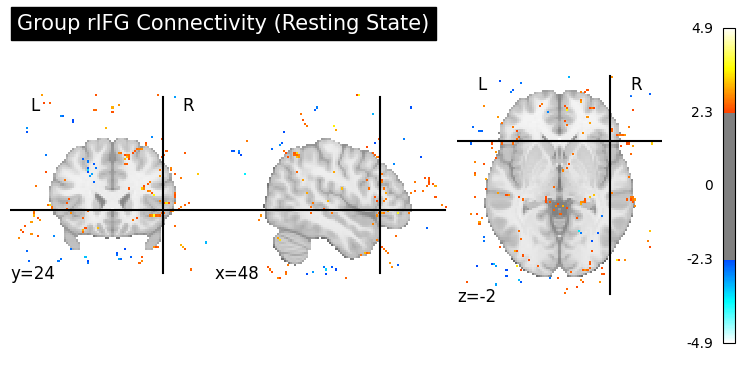

In [ ]:
#task8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nilearn import input_data, plotting, image
from nilearn.glm.second_level import SecondLevelModel
import nibabel as nib
import os
import glob


BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']
CANONICAL_RIFG = [48, 24, -2] 

TARGET_ROIS = {
    'PCC': (0, -52, 27),
    'Precuneus': (0, -60, 36),
    'Angular_R': (46, -66, 30),
    'mPFC': (-2, 54, 27)
}

print("================ TASK 8: TARGETED CONNECTIVITY REPORT ================")

results_list = []
seed_maps = []

for sub in SUBJECTS:
    print(f"\n🧠 Analyzing {sub}...")
    sub_dir = os.path.join(BASE_PATH, sub)
    
  
    zmap_path = os.path.join(sub_dir, 'func', 'stopsignal_task', f'{sub}_Stop_vs_Go_zmap.nii.gz')
    rest_dir = os.path.join(sub_dir, 'func', 'rest')
    rest_nii = glob.glob(os.path.join(rest_dir, '*.nii'))[0]
    confounds_file = glob.glob(os.path.join(rest_dir, '*_confounds_full.csv'))[0]
    
    if os.path.exists(zmap_path):
        seed_coords = CANONICAL_RIFG
        coord_status = "Canonical"
    else:
        seed_coords = CANONICAL_RIFG
        coord_status = "Default (Map Missing)"
        

    img = nib.load(rest_nii)
    confounds_df = pd.read_csv(confounds_file).iloc[:img.shape[3], :]
    
    
    seed_masker = input_data.NiftiSpheresMasker(
        [seed_coords], radius=6, detrend=True, standardize=True,
        low_pass=0.08, high_pass=0.009, t_r=2.0
    )
    seed_ts = seed_masker.fit_transform(rest_nii, confounds=confounds_df)
    
    
    target_masker = input_data.NiftiSpheresMasker(
        list(TARGET_ROIS.values()), radius=6, detrend=True, standardize=True,
        low_pass=0.08, high_pass=0.009, t_r=2.0
    )
    target_ts = target_masker.fit_transform(rest_nii, confounds=confounds_df)
    
 
    corr = np.dot(seed_ts.T, target_ts) / seed_ts.shape[0]
    fisher_z = np.arctanh(corr).flatten()
    
    row = {
        'Subject': sub,
        'Seed_Coords_MNI': str(seed_coords),
        'Seed_Type': coord_status
    }
    
    for i, name in enumerate(TARGET_ROIS.keys()):
        row[f'rIFG_to_{name}'] = round(fisher_z[i], 3) # گرد کردن تا 3 رقم اعشار
        
    results_list.append(row)

    
    print("   -> Computing whole-brain map (please wait)...")
    from nilearn.image import clean_img, math_img, new_img_like
    
    clean_nii = clean_img(
        rest_nii, confounds=confounds_df,
        detrend=True, standardize=True,
        low_pass=0.08, high_pass=0.009, t_r=2.0
    )
    clean_data = clean_nii.get_fdata()
    seed_corr = np.dot(clean_data, seed_ts) / clean_data.shape[3]
    
    
    seed_corr = np.clip(seed_corr, -0.999, 0.999)
    seed_z_img = new_img_like(clean_nii, np.arctanh(seed_corr))
    
    seed_maps.append(seed_z_img)


print("\n" + "="*60)
print("📊 FINAL TABLE: rIFG Connectivity Profile (Fisher-Z)")
print("="*60)
df_results = pd.DataFrame(results_list)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results)
print("="*60 + "\n")

if len(seed_maps) == len(SUBJECTS):
    design_matrix = pd.DataFrame({'intercept': [1] * len(seed_maps)})
    second_level = SecondLevelModel(smoothing_fwhm=6.0).fit(seed_maps, design_matrix=design_matrix)
    group_map = second_level.compute_contrast(output_type='z_score')
    
    print("Visualizing Group Map...")
    plotting.plot_stat_map(
        group_map, threshold=2.3,
        title='Group rIFG Connectivity (Resting State)',
        cut_coords=CANONICAL_RIFG,
        display_mode='ortho', cmap='cold_hot'
    )
    plt.show()



🧠 Running PPI for sub-1...


C:\Users\user\AppData\Local\Temp\ipykernel_3960\3992083054.py:64: UserWarning: The following unexpected columns in events data will be ignored: SubjectResponseCorrectness, PresentedStimulusArrowDirection, onset_noTriggerAdjust, StopSignalDelay, TrialOutcome, LadderNumber, SubjectResponseButtonCode, LadderMovement, ReactionTime, TimeCourse_noTriggerAdjust, SubjectResponseButton, TimeCourse, LadderTime
  design_matrix_base = make_first_level_design_matrix(
C:\Users\user\AppData\Local\Temp\ipykernel_3960\3992083054.py:100: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ppi_glm = ppi_glm.fit(nii_file, design_matrices=final_dm)


   -> Fitting PPI GLM...
   -> Visualizing sub-1...


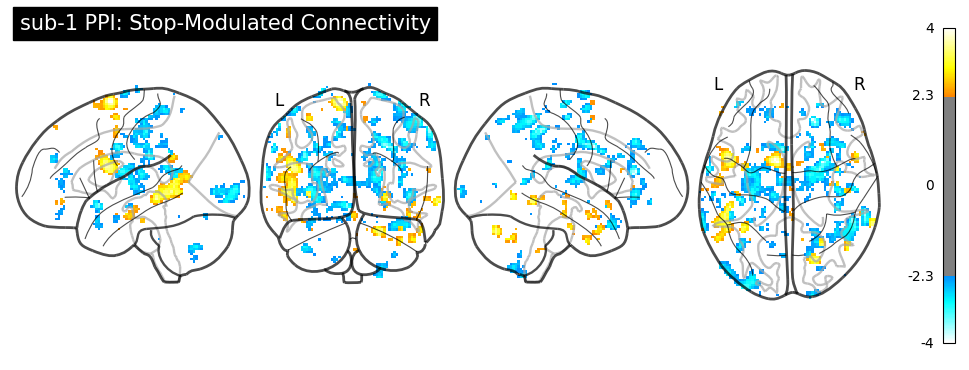

C:\Users\user\AppData\Local\Temp\ipykernel_3960\3992083054.py:125: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(


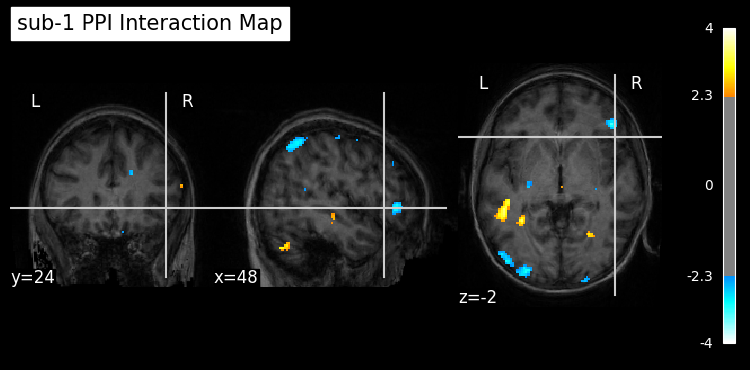


🧠 Running PPI for sub-2...


C:\Users\user\AppData\Local\Temp\ipykernel_3960\3992083054.py:64: UserWarning: The following unexpected columns in events data will be ignored: SubjectResponseCorrectness, PresentedStimulusArrowDirection, onset_noTriggerAdjust, StopSignalDelay, TrialOutcome, LadderNumber, SubjectResponseButtonCode, LadderMovement, ReactionTime, TimeCourse_noTriggerAdjust, SubjectResponseButton, TimeCourse, LadderTime
  design_matrix_base = make_first_level_design_matrix(
C:\Users\user\AppData\Local\Temp\ipykernel_3960\3992083054.py:100: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  ppi_glm = ppi_glm.fit(nii_file, design_matrices=final_dm)


   -> Fitting PPI GLM...
   -> Visualizing sub-2...


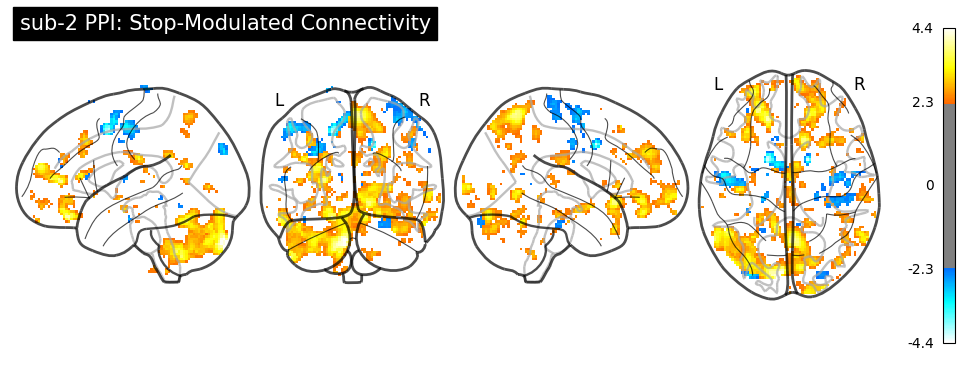

C:\Users\user\AppData\Local\Temp\ipykernel_3960\3992083054.py:125: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(


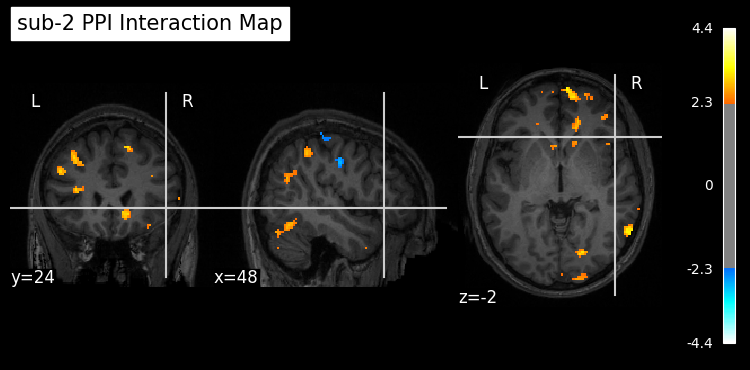

In [ ]:
#Step 9

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nilearn import input_data, plotting, image
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.glm.second_level import SecondLevelModel
import nibabel as nib
import os
import glob
from scipy.stats import zscore


BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']
CANONICAL_RIFG = [48, 24, -2] # مختصات استاندارد (Canonical Seed)



ppi_maps = []

for sub in SUBJECTS:
    print(f"\n🧠 Running PPI for {sub}...")
    sub_dir = os.path.join(BASE_PATH, sub)
    task_dir = os.path.join(sub_dir, 'func', 'stopsignal_task')
    
    # 1. بارگذاری فایل‌ها
    try:
        nii_file = glob.glob(os.path.join(task_dir, '*task-stopsignal_bold.nii'))[0]
        events_file = glob.glob(os.path.join(task_dir, '*events.tsv'))[0]
        confounds_file = glob.glob(os.path.join(task_dir, '*_confounds_full.csv'))[0]
    except IndexError:
        print(f"    Error: Files not found for {sub}. Skipping.")
        continue
    
    img = nib.load(nii_file)
    n_scans = img.shape[3]
    tr = float(img.header.get_zooms()[3])
    frame_times = np.arange(n_scans) * tr
    
   
    confounds_df = pd.read_csv(confounds_file).iloc[:n_scans, :]
    
    events_df = pd.read_csv(events_file, sep='\t')

    events_df['trial_type'] = events_df['trial_type'].str.upper().str.strip()
    

    replace_map = {
        'GO CORRECT': 'GO', 'GO': 'GO',
        'STOP SUCCESS': 'STOP', 'STOP': 'STOP',
        'STOP FAILURE': 'STOP_FAIL' 
    }
    events_df['trial_type'] = events_df['trial_type'].replace(replace_map)
    events_df = events_df[events_df['trial_type'].isin(['GO', 'STOP'])]
    seed_masker = input_data.NiftiSpheresMasker(
        [CANONICAL_RIFG], radius=6,
        detrend=True, standardize='zscore_sample',
        low_pass=0.1, high_pass=0.01, t_r=tr
    )
  
    physio_signal = seed_masker.fit_transform(nii_file, confounds=confounds_df)
    design_matrix_base = make_first_level_design_matrix(
        frame_times, events_df, hrf_model='spm', drift_model='cosine', high_pass=0.01, oversampling=1
    )

    design_matrix_base = design_matrix_base.iloc[:n_scans, :]
    
 
    dm_cols = design_matrix_base.columns
    col_stop = [c for c in dm_cols if 'STOP' in c and 'FAIL' not in c]
    col_go = [c for c in dm_cols if 'GO' in c]
    
    if col_stop and col_go:
        psycho_vector = design_matrix_base[col_stop[0]].values - design_matrix_base[col_go[0]].values
    else:
        print(f"    Error: Could not find pure STOP/GO columns. Found: {dm_cols}")
        continue

 
    ppi_interaction = physio_signal.flatten() * zscore(psycho_vector)
    

    final_dm = design_matrix_base.copy()
    final_dm['Physio_Seed'] = physio_signal
    final_dm['PPI_Interaction'] = ppi_interaction
    
 
    final_dm.reset_index(drop=True, inplace=True)
    confounds_df.reset_index(drop=True, inplace=True)
    final_dm = pd.concat([final_dm, confounds_df], axis=1)
    
   
    final_dm = final_dm.loc[:, ~final_dm.columns.duplicated()]
    final_dm = final_dm.iloc[:n_scans, :]

    print("   -> Fitting PPI GLM...")
    ppi_glm = FirstLevelModel(t_r=tr, noise_model='ar1', standardize=False, minimize_memory=False)
    ppi_glm = ppi_glm.fit(nii_file, design_matrices=final_dm)
    
    z_map_ppi = ppi_glm.compute_contrast('PPI_Interaction', output_type='z_score')
    
    # ذخیره فایل
    save_path = os.path.join(task_dir, f'{sub}_PPI_Stop-Go_zmap.nii.gz')
    z_map_ppi.to_filename(save_path)
    ppi_maps.append(save_path)
    
    
    print(f"   -> Visualizing {sub}...")
    
 
    plotting.plot_glass_brain(
        z_map_ppi, 
        threshold=2.3,       
        plot_abs=False,     
        display_mode='lyrz', 
        colorbar=True, 
        cmap='cold_hot',     
        title=f'{sub} PPI: Stop-Modulated Connectivity'
    )
    plt.show()

    # ب) Stat Map (نمای دقیق روی آناتومی)
    plotting.plot_stat_map(
        z_map_ppi,
        threshold=2.3,
        bg_img=os.path.join(sub_dir, 'anat', f'wc{sub}_T1w.nii'), # روی مغز خود فرد
        black_bg=True,       # پس‌زمینه مشکی (حرفه‌ای)
        display_mode='ortho',
        cut_coords=CANONICAL_RIFG, # برش روی ناحیه IFG
        cmap='cold_hot',
        title=f'{sub} PPI Interaction Map'
    )
    plt.show()





   -> Top 15% Threshold: |Z| > 0.960


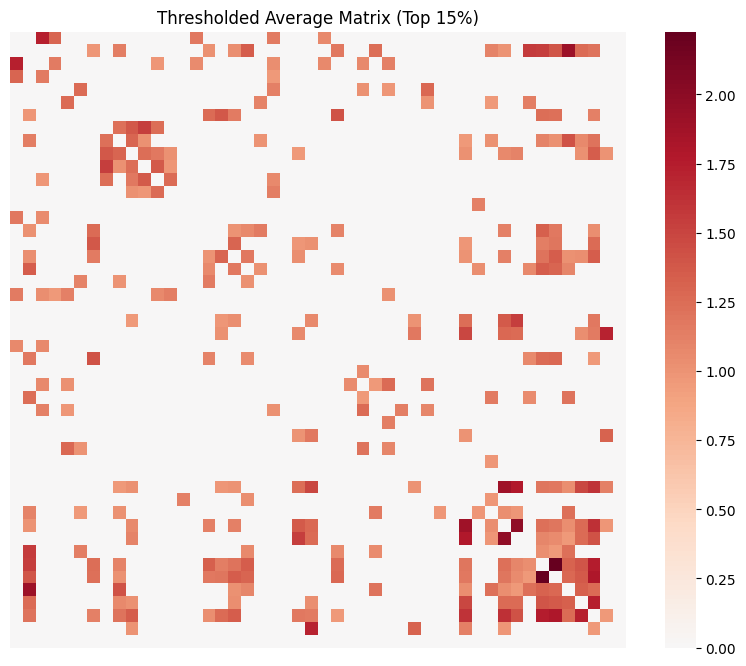


📊 Network Comparison (Mean Metrics):
               DMN     Control
Degree      5.000000  4.750000
Strength    5.417705  5.274516
Clustering  0.309518  0.242490

🏆 Network Hub (Highest Strength): Planum Temporale
--------------------------------------------------
   -> Generating Brain Graph...
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\user\nilearn_data\fsl


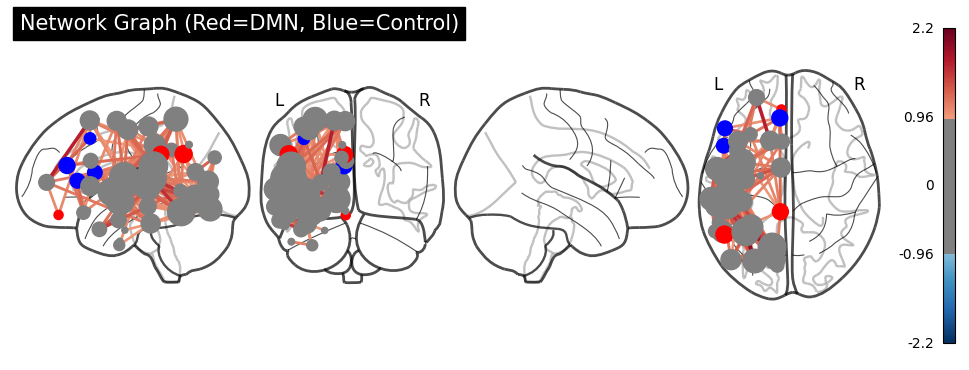

In [ ]:
#step 10
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting, datasets
import networkx as nx
import os
import glob

BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']

DMN_NODES = ['Cingulate Gyrus, posterior', 'Precuneus', 'Frontal Medial Cortex', 'Angular Gyrus']
CONTROL_NODES = ['Middle Frontal Gyrus', 'SupraMarginal Gyrus', 'Paracingulate Gyrus', 'Inferior Frontal Gyrus']

roi_matrices = []
roi_labels = []

for sub in SUBJECTS:
    sub_dir = os.path.join(BASE_PATH, sub, 'func', 'rest')
    csv_path = glob.glob(os.path.join(sub_dir, '*_roi_fisherz.csv'))
    
    if csv_path:
        df = pd.read_csv(csv_path[0], index_col=0)
        roi_matrices.append(df.values)
        roi_labels = df.columns.tolist()
    else:
        print(f"❌ Matrix not found for {sub}")

if not roi_matrices:
    raise ValueError("No matrices found! Run Task 6 first.")

avg_matrix = np.mean(roi_matrices, axis=0)
np.fill_diagonal(avg_matrix, 0) 

threshold_val = np.percentile(np.abs(avg_matrix), 85)
thresholded_matrix = avg_matrix.copy()
thresholded_matrix[np.abs(thresholded_matrix) < threshold_val] = 0

print(f"   -> Top 15% Threshold: |Z| > {threshold_val:.3f}")


plt.figure(figsize=(10, 8))
sns.heatmap(thresholded_matrix, cmap='RdBu_r', center=0, square=True, 
            xticklabels=False, yticklabels=False)
plt.title('Thresholded Average Matrix (Top 15%)')
plt.show()


mapping = {i: label for i, label in enumerate(roi_labels)}
G = nx.relabel_nodes(G, mapping)


degree_dict = dict(G.degree(weight=None)) # تعداد یال‌ها
strength_dict = dict(G.degree(weight='weight')) # مجموع وزن‌ها
clustering_dict = nx.clustering(G, weight='weight')


metrics_df = pd.DataFrame({
    'Node': roi_labels,
    'Degree': [degree_dict.get(l, 0) for l in roi_labels],
    'Strength': [strength_dict.get(l, 0) for l in roi_labels],
    'Clustering': [clustering_dict.get(l, 0) for l in roi_labels]
}).set_index('Node')

# 4. مقایسه DMN vs Control
def get_network_stats(node_list, metrics_df):

    valid_nodes = []
    for keyword in node_list:
        valid_nodes.extend([n for n in metrics_df.index if keyword in n])
    
    if not valid_nodes:
        return None
    return metrics_df.loc[valid_nodes].mean()

dmn_stats = get_network_stats(DMN_NODES, metrics_df)
control_stats = get_network_stats(CONTROL_NODES, metrics_df)

print("\n📊 Network Comparison (Mean Metrics):")
comp_df = pd.DataFrame({'DMN': dmn_stats, 'Control': control_stats})
print(comp_df)


hub_node = metrics_df['Strength'].idxmax()
print(f"\n🏆 Network Hub (Highest Strength): {hub_node}")
print("-" * 50)

# 5. رسم گراف نهایی (Network Visualization)
print("   -> Generating Brain Graph...")
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
coords = plotting.find_parcellation_cut_coords(atlas.maps)

# رنگ‌بندی نودها (DMN=قرمز، Control=آبی، بقیه=خاکستری)
node_colors = []
for label in roi_labels:
    if any(k in label for k in DMN_NODES):
        node_colors.append('red')
    elif any(k in label for k in CONTROL_NODES):
        node_colors.append('blue')
    else:
        node_colors.append('gray')


plotting.plot_connectome(
    avg_matrix, coords,
    edge_threshold=f"{85}%",
    node_color=node_colors,
    node_size=[v * 20 for v in metrics_df['Strength']],
    display_mode='lyrz',
    title=f'Network Graph (Red=DMN, Blue=Control)',
    edge_cmap='RdBu_r',
    colorbar=True
)
plt.show()





📊 Detailed Network Metrics Table:
Network                    Node                    Degree  Strength  Clustering
Control                       Paracingulate Gyrus    6      6.564      0.136   
Control Inferior Frontal Gyrus, pars triangularis    5      5.646      0.249   
Control  Inferior Frontal Gyrus, pars opercularis    5      5.477      0.053   
Control                      Middle Frontal Gyrus    3      3.412      0.532   
    DMN                             Angular Gyrus    7      7.507      0.165   
    DMN       Cingulate Gyrus, posterior division    6      6.599      0.198   
    DMN                     Frontal Medial Cortex    2      2.147      0.565   


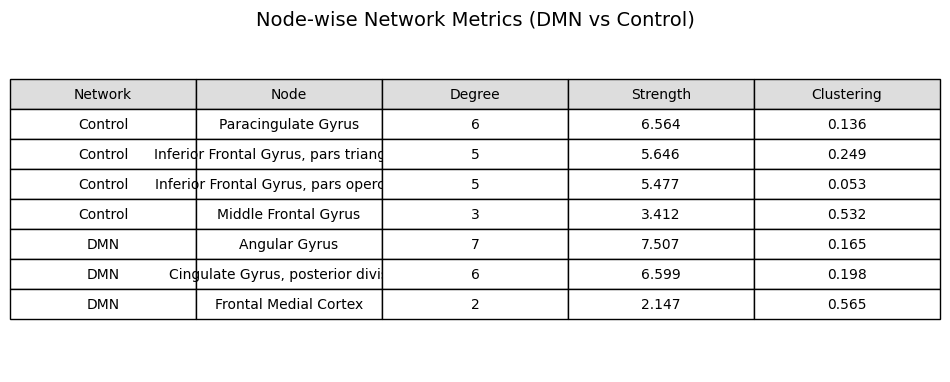

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob


BASE_PATH = r"C:\Users\user\OneDrive\Desktop\project\data.project\data.project"
SUBJECTS = ['sub-1', 'sub-2']


DMN_KEYWORDS = ['Cingulate Gyrus, posterior', 'Precuneus', 'Frontal Medial Cortex', 'Angular Gyrus']
CONTROL_KEYWORDS = ['Middle Frontal Gyrus', 'SupraMarginal Gyrus', 'Paracingulate Gyrus', 'Inferior Frontal Gyrus']




roi_matrices = []
roi_labels = []

for sub in SUBJECTS:
    sub_dir = os.path.join(BASE_PATH, sub, 'func', 'rest')
    csv_path = glob.glob(os.path.join(sub_dir, '*_roi_fisherz.csv'))
    if csv_path:
        df = pd.read_csv(csv_path[0], index_col=0)
        roi_matrices.append(df.values)
        roi_labels = df.columns.tolist()

if roi_matrices:
    avg_matrix = np.mean(roi_matrices, axis=0)
    np.fill_diagonal(avg_matrix, 0)
    threshold_val = np.percentile(np.abs(avg_matrix), 85)
    thresh_mat = avg_matrix.copy()
    thresh_mat[np.abs(thresh_mat) < threshold_val] = 0
    
    # ساخت گراف
    G = nx.from_numpy_array(np.abs(thresh_mat))
    

    degree = dict(G.degree()) 
    strength = dict(G.degree(weight='weight'))
    clustering = nx.clustering(G, weight='weight') 
    
 
    table_rows = []
    
    for i, label in enumerate(roi_labels):
        network = None
        
      
        if any(k in label for k in DMN_KEYWORDS):
            network = 'DMN'
        elif any(k in label for k in CONTROL_KEYWORDS):
            network = 'Control'
            
        
        if network:
            table_rows.append({
                'Network': network,
                'Node': label,
                'Degree': int(degree[i]),      # عدد صحیح
                'Strength': round(strength[i], 3), # ۳ رقم اعشار
                'Clustering': round(clustering[i], 3)
            })
            
    # تبدیل به دیتافریم
    df_final = pd.DataFrame(table_rows)
    
    df_final = df_final.sort_values(by=['Network', 'Strength'], ascending=[True, False])
    
    # --- نمایش و ذخیره ---
    print("\n📊 Detailed Network Metrics Table:")
 
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.colheader_justify', 'center')
    
    print(df_final.to_string(index=False)) 
  
    fig, ax = plt.subplots(figsize=(10, len(df_final)*0.5 + 1)) 
    ax.axis('tight')
    ax.axis('off')
    
    # رسم جدول
    the_table = ax.table(
        cellText=df_final.values,
        colLabels=df_final.columns,
        cellLoc='center',
        loc='center',
        colColours=['#dddddd']*len(df_final.columns)
    )
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(10)
    the_table.scale(1.2, 1.8)
    
    plt.title('Node-wise Network Metrics (DMN vs Control)', fontsize=14, y=0.98)
    plt.show()

else:
    print("❌ Error: Matrices not found.")
